### State 정의: 그래프의 입력 스키마와 출력 스키마 정의하기

In [4]:
from typing import TypedDict, Annotated
from operator import add

# 그래프 객체를 생성할 때 State 전달 해야 하므로, 객체 생성 전에 State 정의부터 작업을 해야 함.
# 입력 상태 -> 문자열 타입을 입력
class InputState(TypedDict): 
    question: str

# 출력 상태 -> 문자열 타입의 출력
class OutputState(TypedDict):
    answer: str

# 내부 (노드끼리) 공유할 상태
class OverallState(TypedDict):
    messages: Annotated[list[str], add]
    question: str
    answer: str

### 그래프 객체 생성

In [5]:
from langgraph.graph import StateGraph

# 상태 그래프 StateGraph는 상태를 읽고 쓰는 방식으로 통신하는 그래프.
graph = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState
)

### 노드 생성과 추가: 함수 정의

In [6]:
# 사용자의 질문을 받아서 llm에게 전달해서 답변을 추가.
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

# 기본 모델: gpt-3.5-turbo
llm = ChatOpenAI(model = "gpt-4o-mini")

# 노드(함수) 정의
def chatbot(state: InputState) -> OverallState:
    question: str = state['question'] # 사용자 질문
    response = llm.invoke(question) # llm에게 답변을 가져오기
    print(response)

    return {
        'answer': response.content,
        'messages': [question, response.content]
    }

# 그래프에 노드 추가
graph.add_node('chatbot', chatbot)


### 엣지 연결 및 컴파일

In [8]:
# 엣지 연결
from langgraph.graph import START, END

graph.add_edge(START, 'chatbot') # 시작 후에 chatbot 노드로 연결
graph.add_edge('chatbot', END) # chatbot 노드에서 종료로 연결
graph2 = graph.compile()

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


### 그래프 시각화

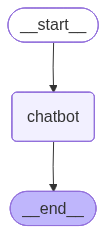

In [10]:
from IPython.display import Image, display

try: 
    display(Image(graph2.get_graph().draw_mermaid_png()))
except Exception:
    pass


### 그래프 실행

In [11]:
graph2.invoke({'question': '대한민국의 수도는 어디인가?'})

content='대한민국의 수도는 서울입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 15, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'id': 'chatcmpl-E1T1MlCV9XRROSh1BfDS2dX7GQhEb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f5fcb-58bb-7b52-a5f5-84d712a0113e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 8, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'answer': '대한민국의 수도는 서울입니다.'}